<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/spare_categorical_CE_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from keras.layers import (
    Conv1D, MaxPooling1D, Dense, BatchNormalization,
    GlobalAveragePooling1D, Dropout, Add, Input
)

from keras.models import Model

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive

In [3]:
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


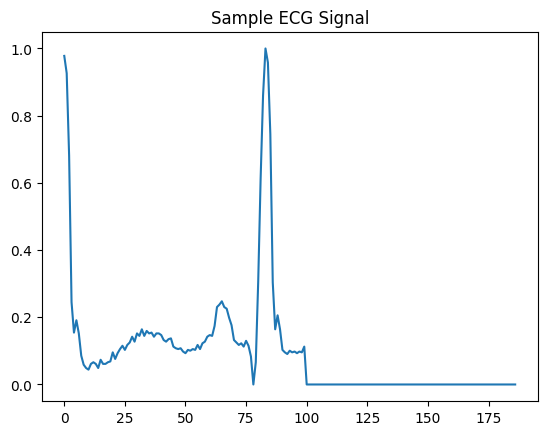

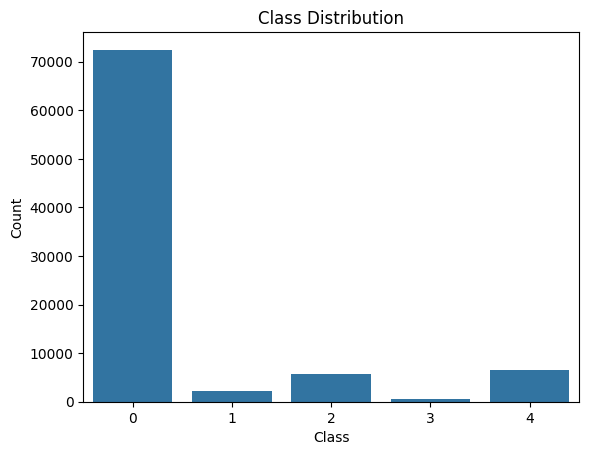

Train Missing: 0
Test Missing : 0


In [4]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()

sns.barplot(x=[0,1,2,3,4], y=counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

print("Train Missing:", train.isna().sum().sum())
print("Test Missing :", test.isna().sum().sum())

In [5]:
from sklearn.preprocessing import StandardScaler

X_train = train.iloc[:, :-1].values.astype(np.float32)
y_train = train.iloc[:, -1].values

X_test = test.iloc[:, :-1].values.astype(np.float32)
y_test = test.iloc[:, -1].values

# Scale while data is still 2D
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Now reshape for CNN
X_test = X_test.reshape(-1, 187, 1)

y_test_cat = to_categorical(y_test, 5)

In [6]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x

In [7]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32, 3, activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x, 64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [8]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_train[train_idx], X_train[val_idx]
    y_tr, y_va = y_train[train_idx], y_train[val_idx]

    smote = SMOTE(random_state=42)

    X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

    # reshape for CNN
    X_tr = X_tr.reshape(-1, 187, 1)
    X_va = X_va.reshape(-1, 187, 1)

    model = resnet_ecg()

    model.fit(
        X_tr, y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)

print("\nMean CV:", np.mean(cv_accuracies))
print("Std CV :", np.std(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - accuracy: 0.9375 - loss: 0.1832
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9767 - loss: 0.0710
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9848 - loss: 0.0469
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9894 - loss: 0.0329
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9919 - loss: 0.0255
Fold 1 Accuracy: 0.9793

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.9369 - loss: 0.1840
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9762 - loss: 0.0715
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9846 - loss: 0.0478
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9888 - loss: 0.0342
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9916 - loss: 0.0259
Fold 2 Accuracy: 0.9720

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 52s 1

In [9]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

smote = SMOTE(random_state=42)

X_train_final, y_train_final = smote.fit_resample(
    X_train_final, y_train_final
)

X_train_final = X_train_final.reshape(-1, 187, 1)
X_val_final   = X_val_final.reshape(-1, 187, 1)


In [19]:
model = resnet_ecg()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.9411 - loss: 0.1730 - val_accuracy: 0.9381 - val_loss: 0.1845
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9778 - loss: 0.0673 - val_accuracy: 0.9666 - val_loss: 0.1307
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.9858 - loss: 0.0428 - val_accuracy: 0.9351 - val_loss: 0.2155
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9901 - loss: 0.0308 - val_accuracy: 0.9713 - val_loss: 0.1228
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 83s 9ms/step - accuracy: 0.9922 - loss: 0.0242 - val_accuracy: 0.9744 - val_loss: 0.0979
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9793 - val_loss: 0.1130
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9946 - loss: 0.0167 - val_accuracy: 0.9719 - val_loss: 0.1220
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9955 - loss: 

In [20]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = y_val_final

print("Validation MCC:", matthews_corrcoef(y_val_true, y_val_pred))

548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Validation MCC: 0.9190549443191653


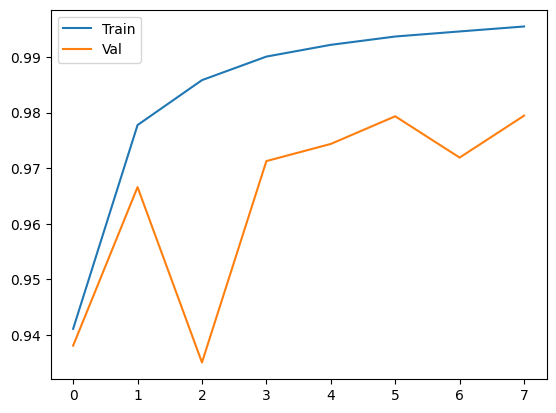

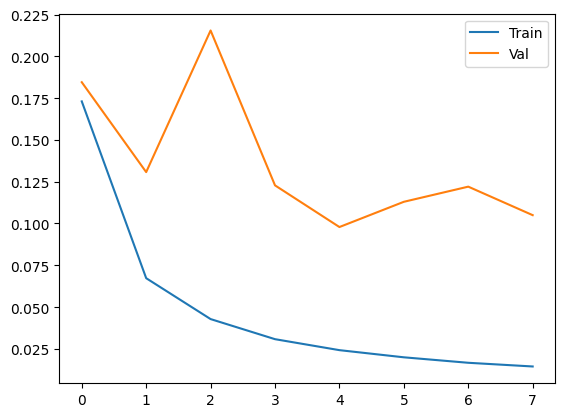

In [21]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.show()

Test Accuracy: 0.9711766839027405
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98     18118
         1.0       0.65      0.79      0.71       556
         2.0       0.92      0.95      0.93      1448
         3.0       0.66      0.87      0.75       162
         4.0       0.97      1.00      0.98      1608

    accuracy                           0.97     21892
   macro avg       0.84      0.92      0.87     21892
weighted avg       0.97      0.97      0.97     21892



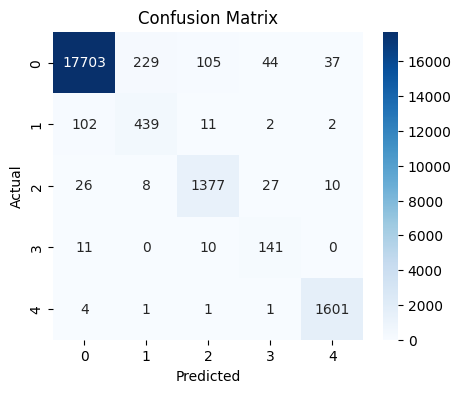

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
# Training metrics (last epoch)

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

# Test metrics

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")

print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")

print(f"Testing Accuracy    : {test_acc:.4f}")
print(f"Testing Loss        : {test_loss:.4f}")

Training Accuracy   : 0.9955
Validation Accuracy : 0.9794
Training Loss       : 0.0145
Validation Loss     : 0.1050
Testing Accuracy    : 0.9712
Testing Loss        : 0.1171
